# Tutorial: Classifier Accuracy
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> H. B. Prosper<br>


## Introduction

In the notebook `tutorial_2D_binary_classifier`, a simple classifier is built to classify the points in the 2D 2-Gaussian dataset. In this notebook we compare the approximate classifier to the exact one. The probability density of the bivariate normal (with $d = 2$) is given by
\begin{align}
\mathcal{N}(x, \mu, \Sigma) & = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2} } \exp\left(-\tfrac{1}{2} z^T \Sigma^{-1} z \right),
\end{align}
where
\begin{align}
    x & = \begin{bmatrix}
            x_1 \\ x_2
            \end{bmatrix}, \quad
    \mu  = \begin{bmatrix}
            \mu_1 \\ \mu_2
            \end{bmatrix}, \quad
    z  = \begin{bmatrix}
            x_1 - \mu_1 \\ x_2 - \mu_2
            \end{bmatrix},\\
    \Sigma & = \begin{bmatrix}
        \Sigma_{11} & \Sigma_{12}\\
        \Sigma_{21} & \Sigma_{22}
    \end{bmatrix}.
\end{align}
Therefore, the exact classifier is given by
\begin{align}
    p(1 \mid x) & = \frac{\mathcal{N}(x, \mu^{(1)}, \Sigma^{(1)})}{\mathcal{N}(x, \mu^{(1)}, \Sigma^{(1)}) + \mathcal{N}(x, \mu^{(0)}, \Sigma^{(0)})\, / \, \epsilon},
\end{align}
with $\epsilon = \pi(1)\,/\, \pi(0) = 1$ for a **balanced dataset**. The superscripts label the densities of the two classes of points.

In [1]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

import joblib
import importlib

import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat

# module for shell utilities
import shutil

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": shutil.which('latex') is not None, 
    "font.family": "sans-serif",
    "font.size": FONTSIZE
})

# set a seed to ensure reproducibility
seed = 128
rnd  = np.random.RandomState(seed)

## Constants

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

params_file = 'runs/gauss2d/gauss2d_params.pth'

Available device: cpu 


## Import exact density

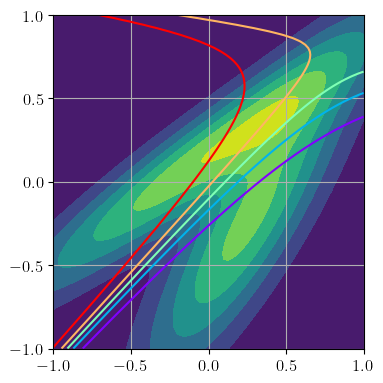

In [3]:
from exactdensity import ExactDensity

fexact = ExactDensity()
fexact.plot()

## Import model

In [4]:
import gauss2d
importlib.reload(gauss2d)

model = gauss2d.model
model.load(params_file)

print(model)
print('number of parameters', mlp.number_of_parameters(model))

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): SiLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): SiLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): SiLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
number of parameters 609


## Compute exact and approximate $p(1 \mid x)$

In [5]:
# exact calculation
x1, x2 = fexact.grid()
pexact = fexact.prob(x1, x2)
print('pexact.shape\t', pexact.shape)

# approximation
# 1. flatten x1 and x2
# 2. stack column-wise 
# 3. convert numpy array to a float32 Tensor
x = np.stack([x1.flatten(), x2.flatten()], axis=1).astype(np.float32)
x = torch.tensor(x)
print('x.shape \t', x.shape)

# 1. reshape(*) - reshape output of model to match that of pexact
# 2. detach()   - detach from computational 
# 3. cpu()      - move to CPU if tensor is not on a CPU, e.g., on GPU
# 4. numpy()    - convert to numpy array (ndarray)
papprox = model(x).reshape(pexact.shape).detach().cpu().numpy()
print('papprox.shape\t', papprox.shape)

pexact.shape	 (101, 101)
x.shape 	 torch.Size([10201, 2])
papprox.shape	 (101, 101)


## Compare exact and approximate $p(1 \mid x)$

Compare contours of constant $p(1 \mid x)$. The solid lines are the results of the exact calculation, while the dashed lines are computed using the ML model.

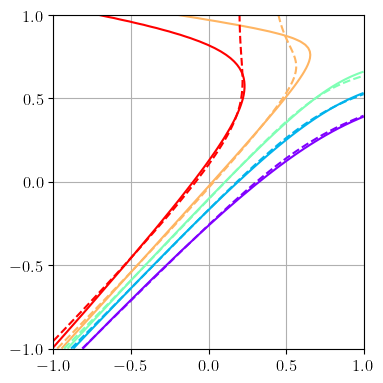

In [6]:
fexact.plot(papprox)

## Comparison of point clouds

Suppose that the prior for the class labeled $y = 1$ is $\pi$, then for a perfect classifier $C_\pi(x)$ we expect
\begin{align}
    C_\pi(x) & = \frac{p(x \mid 1)\, \pi}{p(x)},\\
    & = \frac{p(x \mid 1)\, \pi}{p(x \mid 1)\, \pi + p(x \mid 0)\,(1-\pi)},\\
    & = \frac{{\color{blue}D(x)} \, \pi}{{\color{blue} D(x)}\, \pi + (1 - {\color{blue}D(x)})\,(1-\pi)},
\end{align}
where the discriminant $D(x) = C_{\tfrac{1}{2}}(x)$. It follows from the above that 
\begin{align}
    \mathbb{E}_{x \sim p(x)}[C_\pi] & = \pi .
\end{align}
Now suppose one were to weight a sample drawn from $p(x) =  p(x \mid 1)\, \pi + p(x \mid 0)\,(1-\pi)$ with weights given by $w(x) = C_\pi(x)\, / \, \pi$. Weighting items amounts to constructing a new density given by $p_w(x) = C_\pi(x) \, p(x) \, / \, \pi$. Therefore, for a perfect classifer $C_\pi(x)$ one should get
\begin{align}
    p_w(x) & = p(x \mid 1).
\end{align}
This suggests another way to validate the classifier $C_\pi(x)$ or discriminant $D(x)$; weight $x \sim p(x)$ with $C_\pi(x)\, / \, \pi$ and compare two point clouds, one with $x \sim p(x \mid 1)$ and the other containing weighted points. One might attempt the following:

  1. Bin the sample from class $y = 1$ in some sensible way. 
  3. Bin the weighted sample using the same bins.
  4. Compare the two sequences of counts.
  5. Devise ways to make useful statistical statements about the pair of sequences.

We'll explore the above in notebook `tutorial_point_clouds`.